In [ ]:
!pip install ott-jax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 283.7/283.7 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.4.33
    Uninstalling jaxlib-0.4.33:
      Successfully uninstalled jaxlib-0.4.33
  Attempting uninstall: jax
    Found existing installation: jax 0.4.33
    Uninstalling jax-0.4.33:
      Successfully uninstalled jax-0.4.33


In [ ]:
from functools import partial

import jax
import jax.flatten_util
from jax import random
from jax import numpy as jnp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from google.colab import files
import pickle
from scipy.stats import wasserstein_distance_nd
from ott.geometry import pointcloud
from ott.solvers import linear
rerun: bool = False
def optimal_score(x, samples, sigma, mu):
    exponents = jnp.exp(jnp.sum((-(x - mu * samples) ** 2 / (2 * (sigma ** 2))), axis=1, keepdims=True))
    nominator = mu * samples * exponents
    return jnp.sum(nominator, axis=0) / jnp.sum(exponents) / (sigma ** 2) - x / (sigma ** 2)
batch_optimal_score = jax.vmap(optimal_score, in_axes=[0, None, None, None])
# Toy example with dataset generated by Gaussian
def generate_dataset(d, dataset_size, deviation, key = None):
    if key is None: key = random.key(0)
    subkey = random.split(key, 2)[0]
    X = deviation * random.normal(subkey, shape=(dataset_size, d))
    return X

In [ ]:
def two_layer_nn_diffusion(params, x, t):
    w_1, w_2, b = params
    X = jnp.concat([x, t])
    m = w_1.shape[0]
    return 1 / m * w_2 @ jax.nn.relu(w_1 @ X + b)
batch_two_layer_nn_diffusion = jax.vmap(two_layer_nn_diffusion, in_axes=[None, 0, 0])
def init_params_diffusion(d, m, key):
    subkeys = random.split(key, 2)
    w_1 = random.normal(subkeys[0], (m, d+1)) / jnp.sqrt(d+1)
    w_2 = random.normal(subkeys[1], (d, m))
    b = jnp.zeros((m, ))
    return (w_1, w_2, b)

@jax.jit
def risk_fn_diffusion(params, samples, t, key):
    noise = random.normal(key, shape = samples.shape)
    mu = jnp.exp(-2 * t)
    sigma = jnp.sqrt(1-jnp.exp(-2 * t))
    y = mu * samples + sigma * noise
    return samples.shape[1] * jnp.mean((batch_two_layer_nn_diffusion(params, y, t) - noise)**2)

grad_fn_diffusion = jax.value_and_grad(risk_fn_diffusion, argnums=0)

@partial(jax.jit, static_argnames=["batch_size", "m"])
def sgd_step_diffusion(params, full_dataset, batch_size, key, master_step_size, m, delta = 0.05):
    timesteps = jnp.linspace(delta, 1.0, 100)[::-1]
    subkeys = random.split(key, 3)
    batch = random.choice(subkeys[0], full_dataset, shape=(batch_size, ))
    batch_X = batch[:, :]
    sigmas = 1 / jnp.sqrt(1-jnp.exp(-2 * timesteps))
    batch_t = random.choice(subkeys[1], timesteps, shape=(batch_size, 1), p = sigmas/jnp.sum(sigmas) )
    risk, grad = grad_fn_diffusion(params, batch_X, batch_t, subkeys[2])
    W_1 = params[0] - m * master_step_size * grad[0]
    w_2 = params[1] - m * master_step_size * grad[1]
    b = params[2] - m * master_step_size * grad[2]
    return (W_1, w_2, b), risk

def training_loop_diffusion(dataset_size, batch_size, n_steps, step_size, m, d = 2, delta = 0.05, deviation = 1, key = None):
    if key is None: key = random.key(0)
    subkeys = random.split(key, 3)
    dataset = generate_dataset(d, dataset_size, deviation, subkeys[0])
    params = init_params_diffusion(d, m, subkeys[1])
    subkeys_sgd = random.split(subkeys[2], n_steps)
    timesteps = jnp.linspace(delta, 1.0, 100)
    loss_hist = [0]*n_steps
    for step in tqdm(range(n_steps)):
        params, risk = sgd_step_diffusion(params, dataset, batch_size, subkeys_sgd[step], step_size, m)
        loss_hist[step] = risk
    return loss_hist, params, dataset

In [ ]:
def generate_OU_nn(params, n_samples = 500, delta = 0.05, key = None):
    d = params[1].shape[0]
    print('Start generating samples with nn...')
    timesteps = jnp.linspace(delta, 1.0, 100)[::-1]
    dt = timesteps[0] - timesteps[1]
    if key is None: key = random.key(0)
    subkeys = random.split(key, 2)
    samples = random.normal(subkeys[0], shape=(n_samples, d))
    subkeys_noise = random.split(subkeys[1], len(timesteps))
    with tqdm(total=len(timesteps)) as pbar:
        for i, t in enumerate(timesteps):
            dW = random.normal(subkeys_noise[i], shape=(n_samples, d))
            t_np = jnp.array([t]*n_samples).reshape(n_samples, 1)
            score_value = - 1/jnp.sqrt(1 - jnp.exp(-2 * t_np)) * batch_two_layer_nn_diffusion(params, samples, t_np)
            samples = samples + samples * dt + 2 * score_value * dt + jnp.sqrt(2 * dt) * dW
            pbar.update(1)
    return samples

def generate_OU_optimal(dataset, n_samples = 500, delta = 0.05, key = None):
    d = dataset.shape[1]
    print(f'dimension={d}')
    print('Start generating samples with optimal score...')
    timesteps = jnp.linspace(delta, 1.0, 100)[::-1]
    dt = timesteps[0] - timesteps[1]
    if key is None: key = random.key(0)
    subkeys = random.split(key, 2)
    samples = random.normal(subkeys[0], shape=(n_samples, d))
    subkeys_noise = random.split(subkeys[1], len(timesteps))
    with tqdm(total = len(timesteps)) as pbar:
        for i, t in enumerate(timesteps):
            dW = random.normal(subkeys_noise[i], shape=(n_samples, d))
            mu = jnp.exp(-2 * t)
            sigma = jnp.sqrt(1-jnp.exp(-2 * t))
            score_value = batch_optimal_score(samples, dataset, sigma, mu)
            samples = samples + samples * dt + 2 * score_value * dt + jnp.sqrt(2 * dt) * dW
            pbar.update(1)
    return samples

100%|██████████| 1000000/1000000 [20:31<00:00, 811.81it/s]


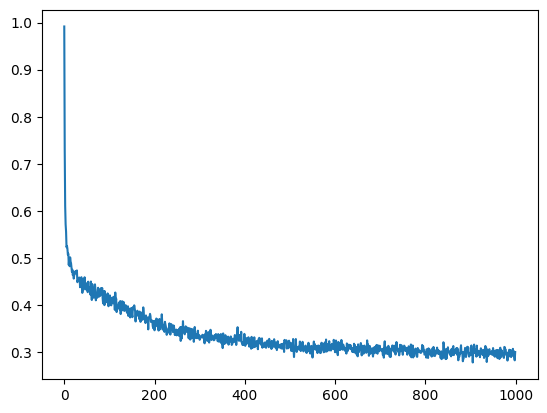

In [ ]:
key = random.key(0)
subkeys = random.split(key, 3)
exp_dict_small_step = {
    'dataset_size': 10,
    'batch_size': 5000,
    'step_size': 1e-3,
    'm': 1000,
    'n_steps': 1_000_000,
    'key': subkeys[0],
    'deviation': 2,
}
loss_hist_small_step, params_small_step, dataset = training_loop_diffusion(**exp_dict_small_step)
plt.plot(loss_hist_small_step[::1000])

100%|██████████| 20000/20000 [00:24<00:00, 831.74it/s]


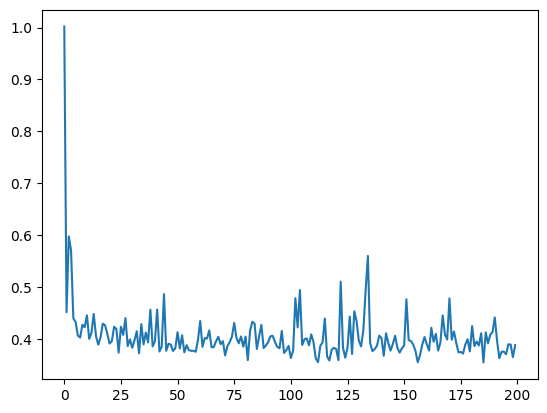

In [ ]:
exp_dict_large_step = {
    'dataset_size': 10,
    'batch_size': 5000,
    'step_size': 1.,
    'm': 1000,
    'n_steps': 20000,
    'key': subkeys[0],
    'deviation': 2
}
loss_hist_large_step, params_large_step, dataset = training_loop_diffusion(**exp_dict_large_step)
plt.plot(loss_hist_large_step[::100])

dimension=2
Start generating samples with nn...


100%|██████████| 100/100 [00:24<00:00,  4.08it/s]


dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:01<00:00, 88.05it/s]


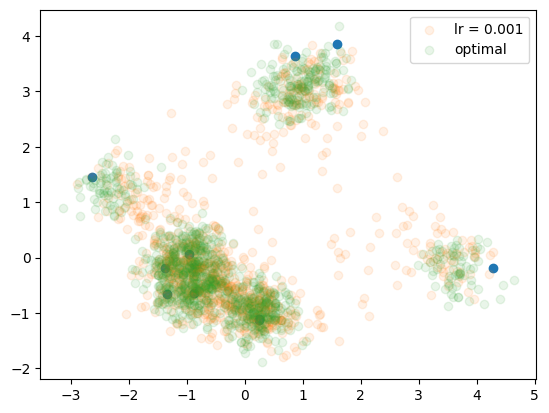

In [ ]:
samples_small_step = generate_OU_nn(params_small_step, 1000, key = subkeys[1])
samples_optimal = generate_OU_optimal(dataset, 1000, key=key)
plt.scatter(dataset[:, 0], dataset[:, 1])
plt.scatter(samples_small_step[:, 0], samples_small_step[:, 1], alpha=.1, label='lr = 0.001')
plt.scatter(samples_optimal[:, 0], samples_optimal[:, 1], alpha=.1, label='optimal')
plt.legend()
# plt.savefig('plot_samples_small_step.pdf', format = 'pdf')
# files.download('plot_samples_small_step.pdf')
plt.show()
# print(f'Wasserstein distance: {wasserstein_distance_nd(samples_small_step, samples_optimal)}')

100%|██████████| 100/100 [00:24<00:00,  4.03it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

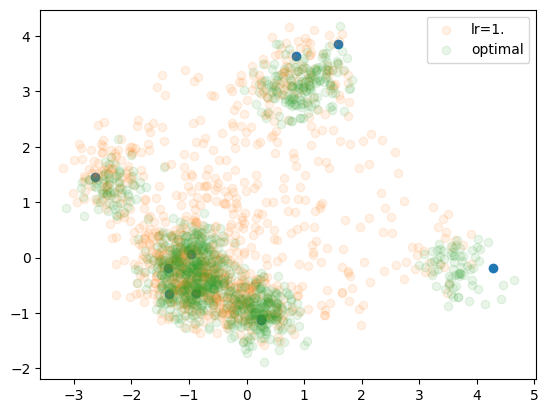

In [ ]:
samples_large_step = generate_OU_nn(params_large_step, 1000, key = subkeys[1])
plt.scatter(dataset[:, 0], dataset[:, 1])
plt.scatter(samples_large_step[:, 0], samples_large_step[:, 1], alpha=.1, label='lr=1.')
plt.scatter(samples_optimal[:, 0], samples_optimal[:, 1], alpha=.1, label='optimal')
plt.legend()
plt.savefig('plot_samples_large_step.pdf', format = 'pdf')
files.download('plot_samples_large_step.pdf')
plt.show()
# print(f'Wasserstein distance: {wasserstein_distance_nd(samples_large_step, samples_optimal)}')

In [ ]:
geom_small = pointcloud.PointCloud(samples_small_step, samples_optimal, epsilon=1e-6)
geom_large = pointcloud.PointCloud(samples_large_step, samples_optimal, epsilon=1e-6)
solve_fn = jax.jit(linear.solve)
ot_large = solve_fn(geom_large)
ot_small = solve_fn(geom_small)
print(f"lr=1.   , 2-Wasserstein, lower bound = {ot_large.dual_cost:.5g}, upper = {ot_large.primal_cost:.5g}")
print(f"lr=0.001, 2-Wasserstein, lower bound = {ot_small.dual_cost:.5g}, upper = {ot_small.primal_cost:.5g}")

lr=1.   , 2-Wasserstein, lower bound = 0.12589, upper = 0.12102
lr=0.001, 2-Wasserstein, lower bound = 0.047535, upper = 0.046492


In [ ]:
res_dict = {
    'params_small_step': params_small_step,
    'params_large_step': params_large_step,
    'loss_hist_small_step': loss_hist_small_step[::1000],
    'loss_hist_large_step': loss_hist_large_step,
    'dataset': dataset,
    'samples_small_step': samples_small_step,
    'samples_large_step': samples_large_step,
    'samples_optimal': samples_optimal,
}
with open('res_memorization.pkl', 'wb') as f:
    pickle.dump(res_dict, f)
files.download('res_memorization.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

100%|██████████| 50000/50000 [00:48<00:00, 1039.07it/s]


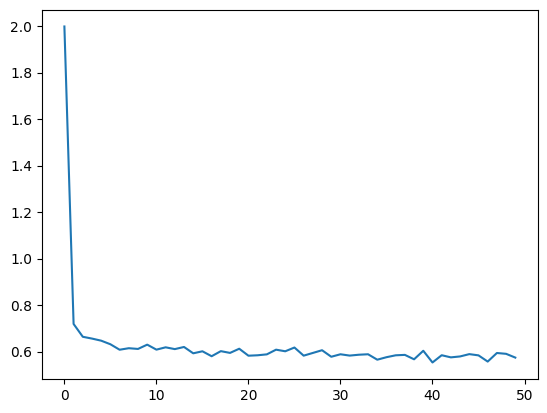

100%|██████████| 50000/50000 [00:49<00:00, 1019.89it/s]


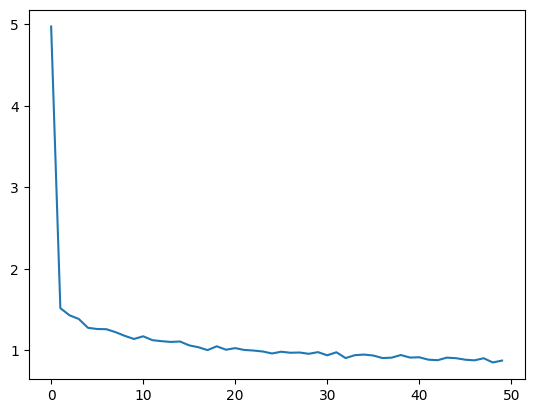

100%|██████████| 50000/50000 [00:48<00:00, 1032.02it/s]


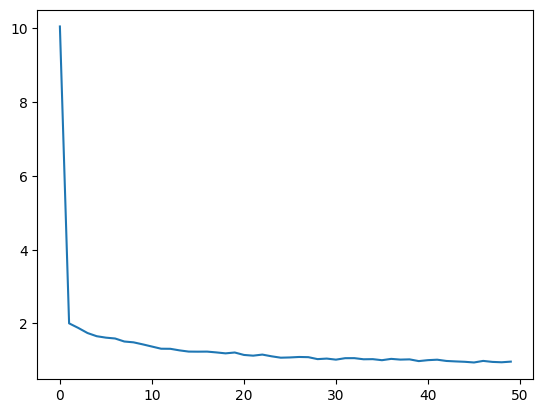

100%|██████████| 50000/50000 [00:48<00:00, 1022.45it/s]


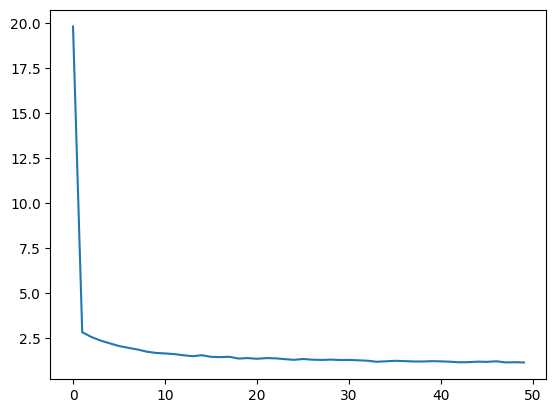

100%|██████████| 50000/50000 [00:41<00:00, 1196.30it/s]


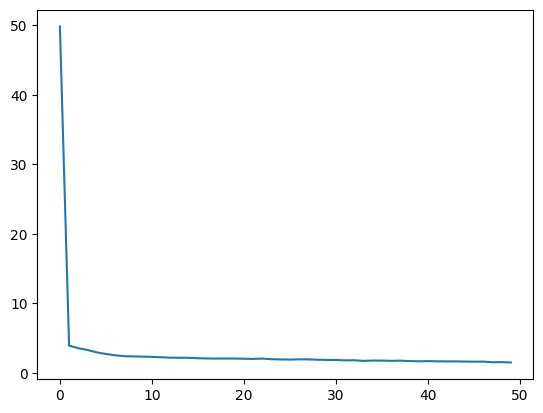

100%|██████████| 50000/50000 [00:41<00:00, 1191.96it/s]


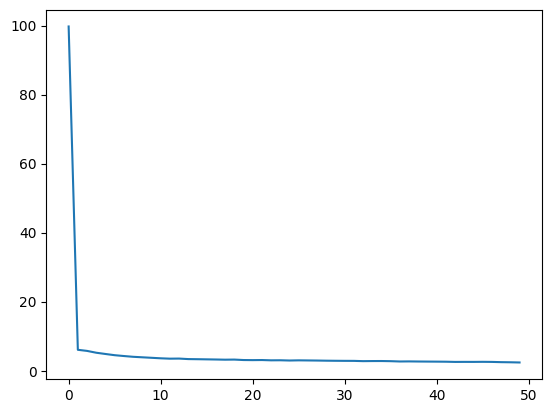

100%|██████████| 50000/50000 [00:48<00:00, 1021.68it/s]


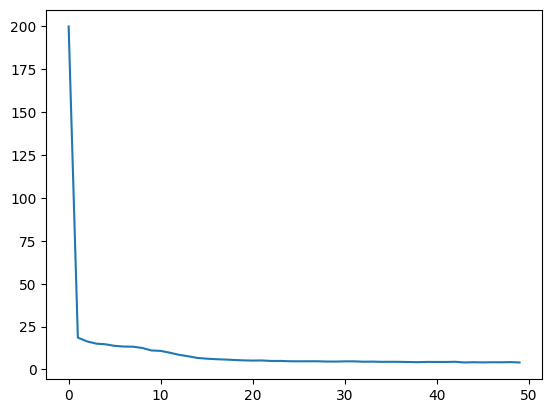

In [ ]:
key = random.key(0)
delta = 0.01
dim_list = [2, 5, 10, 20, 50, 100, 200]
dim_subkeys = random.split(key, len(dim_list))
dist_list = []
for i, d in enumerate(dim_list):
    subkeys = random.split(dim_subkeys[i], 5)
    res = []
    exp_dict_small_step = {
        'dataset_size': 10,
        'batch_size': 5000,
        'step_size': 1e-2,
        'm': 1000,
        'n_steps': 50_000,
        'key': subkeys[0],
        'deviation': 1,
        'd': d,
        'delta': delta
    }
    loss_hist_small_step, params_small_step, dataset = training_loop_diffusion(**exp_dict_small_step)
    plt.plot(loss_hist_small_step[::1000])
    plt.savefig(f'loss_hist_small_step_{d}.pdf', format = 'pdf')
    plt.show()
    # exp_dict_large_step = {
    #     'dataset_size': 200,
    #     'batch_size': 5000,
    #     'step_size': .1,
    #     'm': 1000,
    #     'n_steps': 200_000,
    #     'key': subkeys[0],
    #     'deviation': 1,
    #     'd': d,
    #     'delta': delta
    # }
    # loss_hist, params_large_step, dataset = training_loop_diffusion(**exp_dict_large_step)
    # plt.plot(loss_hist)
    # plt.show()
    res_dict = {
        'dim': d,
        'samples_small_step': params_small_step,
        # 'samples_large_step': params_large_step,
        'dataset': dataset,
    }
    dist_list.append(res_dict)

In [ ]:
with open('dist_list.pkl', 'wb') as f:
    pickle.dump(zip(dim_list, dist_list), f)
files.download('dist_list.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
samples_list = []
key = random.key(0)
subkeys_dim = random.split(key, len(dim_list))
for i, d in enumerate(dist_list):
    print(f'Dimension = {d["dim"]}')
    p = d["dim"]
    subkeys = random.split(subkeys_dim[i], 10)
    samples_ = []
    for j in range(10):
        samples_nn = generate_OU_nn(d["samples_small_step"], 1000, delta=delta, key=subkeys[j])
        samples_.append(samples_nn)
    samples_list.append(samples_)

Dimension = 2
Start generating samples with nn...


100%|██████████| 100/100 [00:17<00:00,  5.75it/s]


Start generating samples with nn...


100%|██████████| 100/100 [00:17<00:00,  5.69it/s]


Start generating samples with nn...


...

100%|██████████| 100/100 [00:17<00:00,  5.88it/s]


Start generating samples with nn...


100%|██████████| 100/100 [00:17<00:00,  5.85it/s]


Start generating samples with nn...


100%|██████████| 100/100 [00:17<00:00,  5.62it/s]


In [ ]:
with open('samples_list.pkl', 'wb') as f:
    pickle.dump(samples_list, f)
files.download('samples_list.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
with open('samples_list.pkl', 'rb') as f:
    samples_list_1 = pickle.load(f)
with open('dist_list.pkl', 'rb') as f:
    dist_list_ = pickle.load(f)
dist_list_1 = []
for _, d in dist_list_:
    dist_list_1.append(d)


In [ ]:
from ott import utils
key = random.key(42)
dim_list = [2, 3, 5, 10, 20, 30]
subkeys_dim = random.split(key, len(dim_list))
res_list = []
def compute_wasserstein_distance(samples_list, dist_list):
    solve_fn = jax.jit(linear.solve)
    for i, (samples, d) in enumerate(zip(samples_list, dist_list)):
        print(f'Dimension = {d["dim"]}')
        subkeys = random.split(subkeys_dim[i], 10)
        res_dict = {'nn_empirical': [], 'nn_true': [], 'true_empirical':[],
                    'nn_empirical_optimal': []}
        for j, sample in enumerate(samples):
            print(f'Round {j+1}')
            samples_true = generate_dataset(d["dim"], 1000, 1, key=subkeys[j])

            geom = pointcloud.PointCloud(sample, d["dataset"], epsilon=.1)
            ot = solve_fn(geom)
            print(f'nn_empirical: {ot.primal_cost=:.5g}, {ot.dual_cost=:.5g}')
            # print(f'nn_empirical_converged: {ot.converged}')
            res_dict["nn_empirical"].append(ot.primal_cost)

            geom = pointcloud.PointCloud(sample, samples_true, epsilon=0.1)
            ot = solve_fn(geom)
            print(f'nn_true: {ot.primal_cost=:.5g}, {ot.dual_cost=:.5g}')
            # print(f'nn_true_converged: {ot.converged}')
            res_dict["nn_true"].append(ot.primal_cost)

            geom = pointcloud.PointCloud(samples_true, d["dataset"], epsilon=0.1)
            ot = solve_fn(geom)
            print(f'true_empirical: {ot.primal_cost=:.5g}, {ot.dual_cost=:.5g}')
            # print(f'true_empirical_converged: {ot.converged}')
            res_dict["true_empirical"].append(ot.primal_cost)

            s = generate_OU_optimal(d['dataset'], 1000, delta=delta, key = subkeys[j])
            geom = pointcloud.PointCloud(sample, s)
            ot = solve_fn(geom)
            print(f'nn_empirical_optimal: {ot.primal_cost=:.5g}, {ot.dual_cost=:.5g}')
            res_dict["nn_empirical_optimal"].append(ot.primal_cost)
        res_list.append(res_dict)
    return res_list
# res_list = compute_wasserstein_distance(samples_list, dist_list)

In [ ]:
res_list = compute_wasserstein_distance(samples_list, dist_list)

Dimension = 2
Round 1
nn_empirical: ot.primal_cost=0.27948, ot.dual_cost=-0.4528
nn_true: ot.primal_cost=0.48559, ot.dual_cost=-0.63728
true_empirical: ot.primal_cost=0.78501, ot.dual_cost=0.062058
dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:01<00:00, 56.85it/s]


nn_empirical_optimal: ot.primal_cost=0.26189, ot.dual_cost=-1.7957
Round 2
nn_empirical: ot.primal_cost=0.30009, ot.dual_cost=-0.43255
nn_true: ot.primal_cost=0.43757, ot.dual_cost=-0.68529
true_empirical: ot.primal_cost=0.77376, ot.dual_cost=0.04953
dimension=2
Start generating samples with optimal score...


100%|██████████| 100/100 [00:01<00:00, 56.08it/s]


nn_empirical_optimal: ot.primal_cost=0.24288, ot.dual_cost=-1.8371
Round 3
nn_empirical: ot.primal_cost=0.2904, ot.dual_cost=-0.44176
nn_true: ot.primal_cost=0.49037, ot.dual_cost=-0.63198
true_empirical: ot.primal_cost=0.80851, ot.dual_cost=0.086371
dimension=2
Start generating samples with optimal score...


...

nn_empirical_optimal: ot.primal_cost=nan, ot.dual_cost=nan
Round 4
nn_empirical: ot.primal_cost=47.661, ot.dual_cost=47.455
nn_true: ot.primal_cost=108.98, ot.dual_cost=108.26
true_empirical: ot.primal_cost=177.51, ot.dual_cost=176.31
dimension=100
Start generating samples with optimal score...


100%|██████████| 100/100 [00:01<00:00, 57.24it/s]


nn_empirical_optimal: ot.primal_cost=nan, ot.dual_cost=nan
Round 5
nn_empirical: ot.primal_cost=47.858, ot.dual_cost=47.718
nn_true: ot.primal_cost=109.74, ot.dual_cost=109.01
true_empirical: ot.primal_cost=178.73, ot.dual_cost=177.45
dimension=100
Start generating samples with optimal score...


100%|██████████| 100/100 [00:01<00:00, 54.70it/s]


KeyboardInterrupt: 

In [ ]:
solve_fn = jax.jit(linear.solve)
samples_list_large = []
key = random.key(0)
subkeys_dim = random.split(key, len(dim_list))
for i, d in enumerate(dist_list):
    print(f'Dimension = {d["dim"]}')
    p = d["dim"]
    subkeys = random.split(subkeys_dim[i], 10)
    samples_ = []
    for j in range(10):
        samples_nn = generate_OU_nn(d["samples_large_step"], 1000, delta=delta, key=subkeys[j])
        samples_.append(samples_nn)
    samples_list_large.append(samples_)

Dimension = 30
dimension=30
Start generating samples with nn...


100%|██████████| 100/100 [00:19<00:00,  5.01it/s]


dimension=30
Start generating samples with nn...


100%|██████████| 100/100 [00:19<00:00,  5.16it/s]


dimension=30
Start generating samples with nn...


...

100%|██████████| 100/100 [00:19<00:00,  5.09it/s]


dimension=50
Start generating samples with nn...


100%|██████████| 100/100 [00:19<00:00,  5.17it/s]


dimension=50
Start generating samples with nn...


100%|██████████| 100/100 [00:20<00:00,  4.99it/s]


In [ ]:
res_list_large_step = compute_wasserstein_distance(samples_list_large, dist_list)

Dimension = 30
Round 1


100%|██████████| 1000/1000 [00:10<00:00, 96.12it/s, error: 1.578806e-01]


nn_empirical: ot.primal_cost=54.869, ot.dual_cost=54.382
nn_empirical_converged: False


100%|██████████| 1000/1000 [00:10<00:00, 93.04it/s, error: 1.256296e-01]


nn_true: ot.primal_cost=60.315, ot.dual_cost=59.793
nn_true_converged: False
Round 2


...

nn_empirical: ot.primal_cost=nan, ot.dual_cost=6.0166e+06
nn_empirical_converged: False


100%|██████████| 1000/1000 [00:10<00:00, 91.78it/s, error: 1.158943e+00]


nn_true: ot.primal_cost=6.6994e+09, ot.dual_cost=6.0173e+06
nn_true_converged: False
Round 3


 24%|██▍       | 240/1000 [00:03<00:10, 73.43it/s, error: 1.790090e-01] 


XlaRuntimeError: INTERNAL: CustomCall failed: CpuCallback error: Traceback (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
  File "/usr/local/lib/python3.10/dist-packages/colab_kernel_launcher.py", line 37, in <module>
  File "/usr/local/lib/python3.10/dist-packages/traitlets/config/application.py", line 992, in launch_instance
  File "/usr/local/lib/python3.10/dist-packages/ipykernel/kernelapp.py", line 619, in start
  File "/usr/local/lib/python3.10/dist-packages/tornado/platform/asyncio.py", line 195, in start
  File "/usr/lib/python3.10/asyncio/base_events.py", line 603, in run_forever
  File "/usr/lib/python3.10/asyncio/base_events.py", line 1909, in _run_once
  File "/usr/lib/python3.10/asyncio/events.py", line 80, in _run
  File "/usr/local/lib/python3.10/dist-packages/tornado/ioloop.py", line 685, in <lambda>
  File "/usr/local/lib/python3.10/dist-packages/tornado/ioloo